# Late Procurement Deliveries – Explainable AI Notebook

## 1. Import Libraries and Set Variables
- Import `pandas` for data manipulation, `numpy` for numerical operations
- Import `scikit-learn` modules for machine learning models, evaluation metrics, and visualization
- Import `matplotlib.pyplot` for visualizations
- Import `shap` library for model interpretability
- Set random seed variable for reproducibility

## 2. Read Data
- Load Excel files for suppliers, materials, warehouses, and procurement transactions
- Add prefixes to column names to identify source tables
- Combine transaction parts into a single DataFrame using merge on the `id` column

## 3. Data Preparation
- Merge supplier information with transaction data
- Create target variable `late` by comparing requested and received dates
- Generate dummy variables for categorical features (supplier, material, warehouse codes)
- Define numeric and categorical features for modeling
- Remove rows with missing values in features
- Split data into training (80%) and test (20%) sets

## 4. Random Forest Model
- Build a Random Forest classifier with controlled depth and tree count
- Evaluate model performance using accuracy, precision, and recall metrics
- Assess model generalization on unseen test data

## 5. Model Interpretability
- Calculate and visualize feature importance from the Random Forest model
- Identify the top features that contribute most to prediction accuracy
- Generate global feature importance rankings and visualizations

## 6. SHAP Analysis
- Create a SHAP TreeExplainer to interpret model predictions
- Generate SHAP values to explain individual predictions
- Create summary plots to visualize feature impacts across the dataset
- Create force plots to explain specific predictions for individual observations
- Analyze how each feature contributes to pushing predictions toward or away from lateness

## 7. Insights and Conclusions
- Interpret the SHAP values to understand which features drive late deliveries
- Identify patterns in the data that lead to procurement delays
- Provide actionable insights for improving procurement processes
- Compare model explanations with business domain knowledge

## 1. Import Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from matplotlib import pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score)
import shap

Get the current working directory

In [2]:
os.getcwd()

'/Users/jan/Documents/02_teaching/fau/course_business_analytics_students/teaching_cases/case_3_predicting_late_purchase_orders'

Set variables


In [3]:
random_var=2025

## 2. Read Data

Define a variable to where files are saved on the pc

<h4><span style="color: red;">This needs very like to be adjusted!!!!</span></h4>

In [4]:
path_to_files = '../case_2_bi_report/data'

Get supplier data

In [5]:
supplier = pd.read_excel(f'{path_to_files}/supplier.xlsx')

Get the column names

In [6]:
supplier.columns

Index(['id', 'name', 'group', 'country', 'street', 'house_number', 'city',
       'postal_code', 'email'],
      dtype='object')

Show the first rows of data

In [7]:
supplier.head()

,id,name,group,country,street,house_number,city,postal_code,email
0,1,Beans Inc.,raw material,Mexico,Broadway Ave,150,New York,10012,info@beansinc.com
1,2,Aromatico,raw material,Italy,Kaffeegasse,27,Bremen,28195,kontakt@aromatico.de
2,3,Farmers of Brazil,raw material,Brazil,Rua do Cafe,72,Sao Paulo,04567-000,contact@farmersofbrazil.br
3,4,Fair Trade AG,raw material,Panama,Friedensstra√üe,10,Zuerich,8001,service@fairtradeag.ch
4,5,Handelskontor Hamburg,raw material,Germany,Speicherstra√üe,3,Hamburg,20457,info@handelskontor.de


Add a suffix to remember from excel file data was read

In [8]:
supplier = pd.read_excel(f'{path_to_files}/supplier.xlsx').add_prefix('supplier_')

Get material data

In [9]:
material = pd.read_excel(f'{path_to_files}/material.xlsx').add_prefix('material_')

Get warehouse data

In [10]:
warehouse = pd.read_excel(f'{path_to_files}/warehouse.xlsx').add_prefix('warehouse_')

Get transaction data

In [11]:
transactions_part_a = pd.read_excel(f'{path_to_files}/procurement_transactions_part_A.xlsx')

In [12]:
transactions_part_b = pd.read_excel(f'{path_to_files}/procurement_transactions_part_B.xlsx')

Check output for transactions part_a

In [13]:
transactions_part_a.head()

,supplier_code,material_code,warehouse_code,logistic_partner_code,id
0,14,c_2,2,6,c9e0d7a4-bbb6-400c-b2b2-4ea3ba04060f
1,14,c_2,7,6,cc543547-3253-4ce0-bf8b-247baf882c0a
2,10,c_1,4,6,6283fc26-1d28-4b95-976a-eec6e83c42b5
3,4,c_0,6,6,a7351547-34e6-4c5c-89c8-0062d94f8d3e
4,4,c_0,3,6,e35b104e-a41c-4712-9753-317e18f5c584


## 3. Data Preparation

### Combine transactions together
use a Left-Join to combine both dataframes via the column ID

In [14]:
transactions = pd.merge(transactions_part_a, transactions_part_b, on='id')

In [15]:
transactions.head()

,supplier_code,material_code,warehouse_code,logistic_partner_code,id,order_date,requested_date,received_date,quantity,price
0,14,c_2,2,6,c9e0d7a4-bbb6-400c-b2b2-4ea3ba04060f,2019-06-06,2019-06-16,2019-06-12 02:00:00,750,3.886901
1,14,c_2,7,6,cc543547-3253-4ce0-bf8b-247baf882c0a,2022-12-28,2023-01-09,2023-01-05 00:00:00,750,6.433883
2,10,c_1,4,6,6283fc26-1d28-4b95-976a-eec6e83c42b5,2019-09-08,2019-09-27,2019-09-25 03:00:00,250,4.848504
3,4,c_0,6,6,a7351547-34e6-4c5c-89c8-0062d94f8d3e,2022-03-30,2022-04-17,2022-04-11 02:00:00,500,56.026029
4,4,c_0,3,6,e35b104e-a41c-4712-9753-317e18f5c584,2019-03-30,2019-04-18,2019-04-14 04:00:00,250,23.635190


### Add Supplier Info

In [16]:
transactions = pd.merge(transactions, supplier, left_on='supplier_code', right_on='supplier_id', how='left')

In [17]:
transactions.columns

Index(['supplier_code', 'material_code', 'warehouse_code',
       'logistic_partner_code', 'id', 'order_date', 'requested_date',
       'received_date', 'quantity', 'price', 'supplier_id', 'supplier_name',
       'supplier_group', 'supplier_country', 'supplier_street',
       'supplier_house_number', 'supplier_city', 'supplier_postal_code',
       'supplier_email'],
      dtype='object')

### Calculate whether a delivery was late

In [18]:
transactions['late'] = transactions['requested_date'] < transactions['received_date']

#### Check Supplier

In [19]:
transactions.groupby('supplier_name')['late'].mean().sort_values(ascending=False)

supplier_name
The Bean Curators           0.993103
Origin Lineage Trading      0.933121
Green Bean Collective       0.736156
RoastWorks Supply Co.       0.582857
Equator Supply Network      0.578947
Humble Roots Trading Co.    0.568254
Farmers of Brazil           0.564470
Small Batch Supply          0.557632
Handelskontor Hamburg       0.361971
Aromatico                   0.356507
Craft Roast Co-Op           0.350678
Beans Inc.                  0.350027
Grindline Partners          0.349147
TerraBean Source Co.        0.348135
Fair Trade AG               0.340690
Name: late, dtype: float64

get column names of transactions

In [20]:
transactions.columns

Index(['supplier_code', 'material_code', 'warehouse_code',
       'logistic_partner_code', 'id', 'order_date', 'requested_date',
       'received_date', 'quantity', 'price', 'supplier_id', 'supplier_name',
       'supplier_group', 'supplier_country', 'supplier_street',
       'supplier_house_number', 'supplier_city', 'supplier_postal_code',
       'supplier_email', 'late'],
      dtype='object')

### Create Dummy Variables

In [21]:
transactions_with_dummies = pd.get_dummies(transactions, columns=['supplier_code', 'material_code', 'warehouse_code'])

#### Define the features (x-Variables)

In [22]:

features = (['quantity', 'price'] + 
            [col for col in transactions_with_dummies.columns if col.startswith('supplier_code_')] +
            [col for col in transactions_with_dummies.columns if col.startswith('material_code_')] + 
            [col for col in transactions_with_dummies.columns if col.startswith('warehouse_code_')]            
            )

In [23]:
features

['quantity',
 'price',
 'supplier_code_1',
 'supplier_code_2',
 'supplier_code_3',
 'supplier_code_4',
 'supplier_code_5',
 'supplier_code_6',
 'supplier_code_7',
 'supplier_code_8',
 'supplier_code_9',
 'supplier_code_10',
 'supplier_code_11',
 'supplier_code_12',
 'supplier_code_13',
 'supplier_code_14',
 'supplier_code_15',
 'material_code_c_0',
 'material_code_c_1',
 'material_code_c_2',
 'material_code_c_3',
 'material_code_c_4',
 'material_code_c_5',
 'material_code_c_6',
 'material_code_c_7',
 'warehouse_code_1',
 'warehouse_code_2',
 'warehouse_code_3',
 'warehouse_code_4',
 'warehouse_code_5',
 'warehouse_code_6',
 'warehouse_code_7']

#### Clean Data for missing values

In [24]:
transactions_with_dummies.dropna(subset=features, inplace=True)

### Test / Train split


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    transactions_with_dummies[features], 
    transactions_with_dummies['late'],
    test_size=0.2, 
    random_state=random_var
)

## 5. Random Forest

In [26]:
rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=random_var)

In [27]:
rf.fit(X=X_train, y=y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



Plot the first 3 trees in the random forest

In [28]:
rf_pred = rf.predict(X_test)


In [29]:
accuracy_score(y_true=y_test, y_pred=rf_pred)

0.6564701147112095

In [30]:
precision_score(y_true=y_test, y_pred=rf_pred)

0.8528428093645485

In [31]:
recall_score(y_true=y_test, y_pred=rf_pred)

0.1329509906152242

## Feature Importance

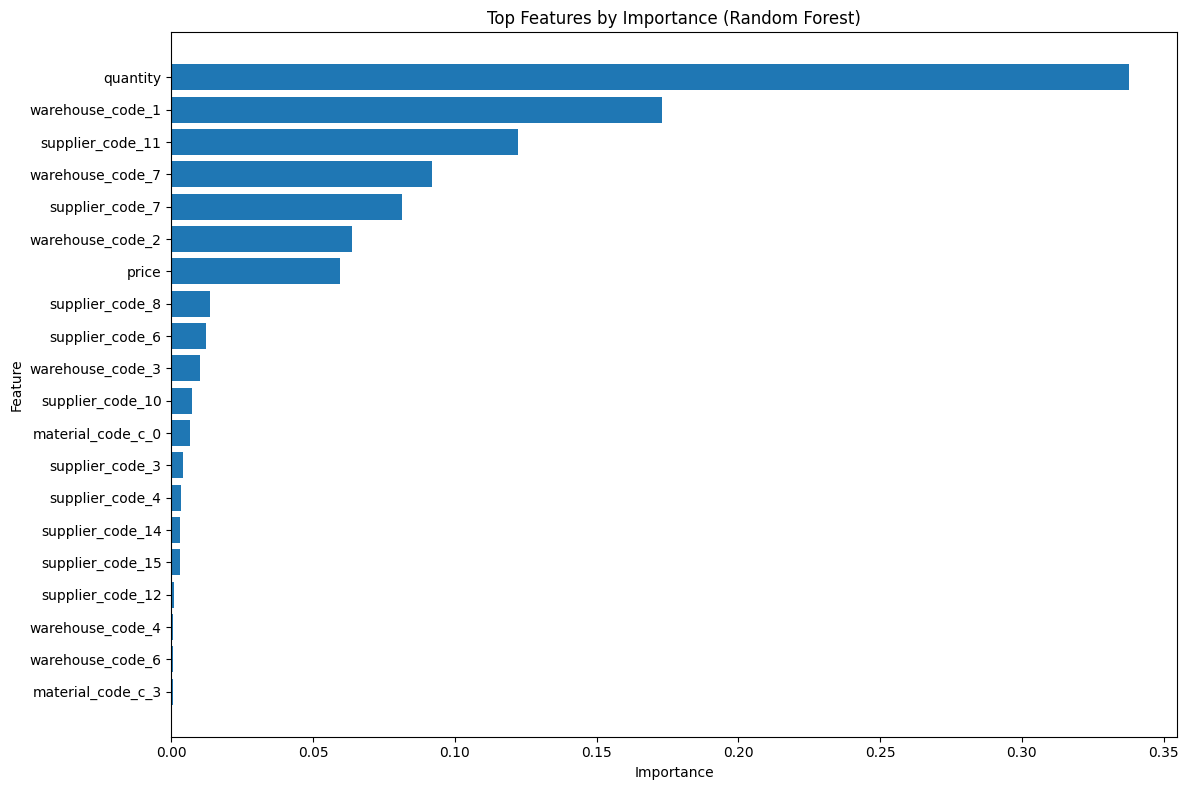

In [32]:
# Get feature importance from the Random Forest model
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort features by importance (descending)

# Create a DataFrame to store feature names and their importance
feature_importance_df = pd.DataFrame({
    'Feature': [features[i] for i in indices],
    'Importance': [importances[i] for i in indices]
})

# Plot the top N most important features
n_features = 20  # You can adjust this number
top_features = feature_importance_df.head(n_features)

plt.figure(figsize=(12, 8))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top Features by Importance (Random Forest)')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=300)
plt.show()

### Shapley Values

#### Create explainer for Random Forest

In [33]:
# Create explainer for Random Forest
explainer_rf = shap.TreeExplainer(
                rf, 
                model_output='probability', 
                data=X_test.astype(int).values
                )

Get expected value

In [34]:
shap_values_rf = explainer_rf.shap_values(X_test)

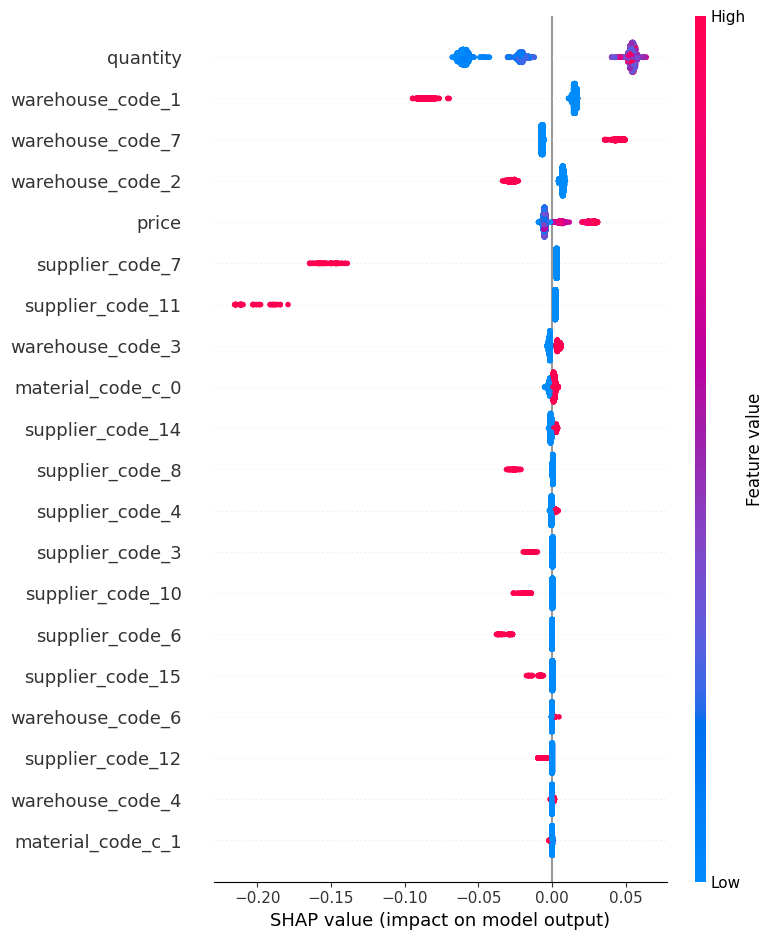

In [35]:
shap.summary_plot(
          shap_values_rf[..., 0], 
          X_test, 
          feature_names=features, 
          max_display=20
        )


In [36]:
shap.initjs()

In [37]:
X_test.iloc[0,:]

quantity                   150
price                45.448396
supplier_code_1          False
supplier_code_2          False
supplier_code_3          False
supplier_code_4           True
supplier_code_5          False
supplier_code_6          False
supplier_code_7          False
supplier_code_8          False
supplier_code_9          False
supplier_code_10         False
supplier_code_11         False
supplier_code_12         False
supplier_code_13         False
supplier_code_14         False
supplier_code_15         False
material_code_c_0         True
material_code_c_1        False
material_code_c_2        False
material_code_c_3        False
material_code_c_4        False
material_code_c_5        False
material_code_c_6        False
material_code_c_7        False
warehouse_code_1         False
warehouse_code_2         False
warehouse_code_3          True
warehouse_code_4         False
warehouse_code_5         False
warehouse_code_6         False
warehouse_code_7         False
Name: 77

In [38]:
explainer_rf.expected_value[1]

np.float64(0.3941766669408507)

In [39]:
obs = 1

In [40]:
shap.force_plot(explainer_rf.expected_value[1],  shap_values_rf[obs][:, 1], X_test.iloc[obs,:][features])